# 6.1 Networks with metadata

#### This notebook shows how to combine structural edges with node metadata using the metadata-dependent random-walk simulator and how to analyze the resulting metadata-aware network with Infomap.

In [1]:
!git clone https://github.com/mapequation/color-map-equation.git

fatal: destination path 'color-map-equation' already exists and is not an empty directory.


In [2]:
!cargo build --release --manifest-path color-map-equation/simulate/Cargo.toml

    Finished `release` profile [optimized] target(s) in 0.13s


In [3]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from infomap import Infomap
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import subprocess
from pathlib import Path
import seaborn as sns
from coloraide import Color
import sys

In [4]:
%reload_ext autoreload
%autoreload 2
import util

#### Create a toy network example.

In [5]:
# The network has 7 nodes.
G = nx.Graph([
    (1, 2),
    (2, 3),
    (3, 1),
    (3, 4),
    (4, 5),
    (4, 6),
    (5, 6),
    (5, 7),
    (6, 7)
])

pos = nx.spring_layout(G, seed=27)

In [6]:
# We assign a categorical metadata label to each node
metadata = {
    1: 1,
    2: 1,
    3: 2,
    4: 1,
    5: 2,
    6: 2,
    7: 2
}

nx.set_node_attributes(G, metadata, "metadata")

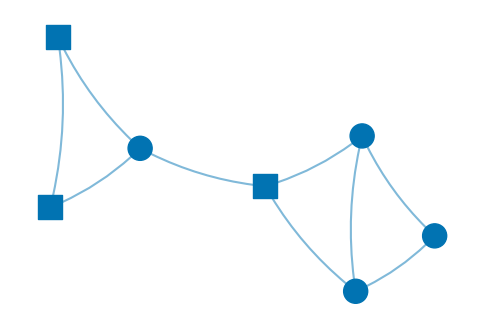

In [7]:
modules = {n: 1 for n in G.nodes}
nx.set_node_attributes(G, modules, "node_color_attr")

# Visualization: metadata 1 = circles, metadata 2 = squares
util.plot_modular_network(
    G,
    pos=pos,
    node_color_attr="node_color_attr",
    figsize=(6, 4),
    edge_width=1.5,
    use_value_as_palette_index=True,
    shape_attr="metadata",
    shape_map={1: "s", 2: "o"},
)

#### Here, we identify modules using the standard map equation.

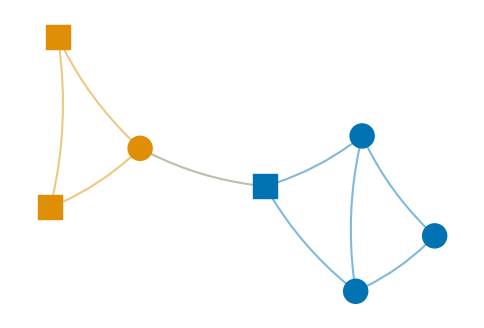

In [8]:
# ---------------------------------------------------------------------
# 1. Detect communities with Infomap (without metadata)
# ---------------------------------------------------------------------

# Standard Infomap run
im = Infomap(
    directed=False,   # Treat G as an undirected graph
    silent=True,      # Suppress terminal output
    num_trials=1      # Single stochastic trial
)

# Load the network into Infomap directly from the NetworkX graph
im.add_networkx_graph(G)
im.run()

# Assign detected modules back to G
nx.set_node_attributes(G, im.get_modules(), "node_color_attr")

# ---------------------------------------------------------------------
# 2. Draw the network
# ---------------------------------------------------------------------

util.plot_modular_network(
    G,
    pos=pos,
    node_color_attr="node_color_attr",
    figsize=(6, 4),
    edge_width=1.5,
    use_value_as_palette_index=True,
    shape_attr="metadata",
    shape_map={1: "s", 2: "o"},
)


#### Here, we use a metadata-dependent encoding of random walks. 

    Finished `dev` profile [unoptimized + debuginfo] target(s) in 0.05s
     Running `color-map-equation/simulate/target/debug/simulate -c fig0.net fig0-meta.txt fig0-meta.net 1.0 0.09 1000000`


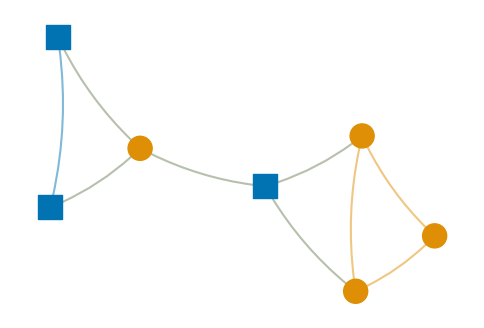

In [9]:
# ---------------------------------------------------------------------
# 1. Prepare data for the metadata-aware simulation
# ---------------------------------------------------------------------

# Baseline encoding probability p ∈ [0, 1]
p = 0.09

# Infomap requires directed edges for rawdir flow model
# Convert the undirected graph G into a directed version H
H = nx.DiGraph()
for u, v in G.edges:
    H.add_edge(u, v)
    H.add_edge(v, u)

# Write the directed edge list to file
nx.write_edgelist(H, "fig0.net", data=False)

# Write node metadata to a separate file.
# Format: "<node> <metadata_value>"
with open("fig0-meta.txt", "w") as fp:
    for node, meta in G.nodes.data("metadata"):
        fp.write(f"{node} {meta}\n")

# ---------------------------------------------------------------------
# 2. Run the metadata-dependent random walk simulation
# ---------------------------------------------------------------------
# The Rust simulator takes:
#   - metadata type flag:   "-c" (categorical) or "-r" (real-valued)
#   - input edge list:      fig0.net
#   - metadata input file:  fig0-meta.txt
#   - output path:          fig0-meta.net
#   - same_prob:            a) 1.0 (neutral encoding)
#                           b) >1 (assortative encoding)
#                           c) >p and <1 (disassortative encoding)
#   - diff_prob:            if <<1, the actual structure of the graph becomes less and ess relevant
#                           if ~1, categorical information becomes irrelevant 
#   - n_samples:            number of random walk steps

!cargo run --manifest-path color-map-equation/simulate/Cargo.toml -- \
    -c fig0.net fig0-meta.txt fig0-meta.net 1.0 {p} 1000000


# ---------------------------------------------------------------------
# 3. Detect communities using Infomap with simulated metadata-aware flow
# ---------------------------------------------------------------------

im = Infomap(flow_model="rawdir", silent=True, num_trials=10)

# Load the metadata-weighted flow network produced by the simulation
im.read_file("fig0-meta.net")
im.run()

# Assign detected module labels back to the original undirected graph G
nx.set_node_attributes(G, im.get_modules(), "node_color_attr")

# ---------------------------------------------------------------------
# 4. Plot the network colored by community and shaped by metadata
# ---------------------------------------------------------------------

util.plot_modular_network(
    G,
    pos=pos,
    node_color_attr="node_color_attr",
    figsize=(6, 4),
    edge_width=1.5,
    use_value_as_palette_index=True,
    shape_attr="metadata",
    shape_map={1: "s", 2: "o"},
)
